# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from uo2009.dgp.params import EfficientPriceParams, NoiseParamsMA2
from uo2009.dgp.simulate import simulate_section4_1_1

from uo2009.dgp.noise import (
    calibrate_diag_innov_vars_for_target_marginals,
    theoretical_covariances_ma,
)

from uo2009.estimators.estimate_cross_covariance_uo import (
    build_Z_pm_selected,
    estimate_cross_covariance_uo_eq11,
)

# Simulate data

In [2]:
# Define DGP parameters
eff_params = EfficientPriceParams()     # uses defaults in params.py
noise_params = NoiseParamsMA2()         # nsr1, nsr2

rng = np.random.default_rng(123) # for reproducibility

out = simulate_section4_1_1(
    eff_params=eff_params,
    noise_params=noise_params,
    delta_seconds=5.0, # sampling every 10 seconds
    rng=rng,
)

y = out.y_obs           # (n_obs, 2)
t_obs = out.t_obs       # (n_obs, 1)

# Observed prices of the two assets
y1_obs = y[:, 0]
y2_obs = y[:, 1]

# Now, we are in the perfectly synchronous observation case:
t1_obs = list(range(t_obs.size))
t2_obs = list(range(t_obs.size))

In [3]:
df = pd.DataFrame({
    't_obs': list(range(len(t_obs))),
    'y1_obs': y1_obs,
    'y2_obs': y2_obs,
})

print(df.head())
print(f"number of observations: {len(df)}")

   t_obs     y1_obs     y2_obs
0      0  -9.840741 -10.063818
1      1   9.328178   9.364834
2      2  11.076427 -18.315462
3      3   1.801340 -10.721667
4      4  -8.334319  -3.640301
number of observations: 4681


# Build ${Z^{\pm}}$ sequence

In [4]:
Z = build_Z_pm_selected(t1_obs, y1_obs, t2_obs, y2_obs, ell=1, m_plus=2, m_minus=2, return_pairs=False, ell_in="ticks")
print(Z[:5])


[-115.15586391 -762.45110302 -302.35865507 -425.38373748  188.57793741]


In [5]:
print(df.head())

   t_obs     y1_obs     y2_obs
0      0  -9.840741 -10.063818
1      1   9.328178   9.364834
2      2  11.076427 -18.315462
3      3   1.801340 -10.721667
4      4  -8.334319  -3.640301


### Calculate by hand

In [6]:
print((y1_obs[5] - y1_obs[3])*(y2_obs[2] - y2_obs[0]))
print((y1_obs[6] - y1_obs[4])*(y2_obs[3] - y2_obs[1]))
print((y1_obs[7] - y1_obs[5])*(y2_obs[4] - y2_obs[2]))

-115.15586391484072
-762.4511030190312
-302.358655071177


# Compute ${\hat{\gamma}(\ell)}$

In [7]:
gamma_1 = estimate_cross_covariance_uo_eq11(
    t1 = t1_obs,
    y1 = y1_obs,
    t2 = t2_obs,
    y2 = y2_obs,
    ell = 1,
    m_plus = 2,
    m_minus = 2,
    ell_in = "ticks"
)

print("Estimated cross-covariance (Eq. 11):", gamma_1)

Estimated cross-covariance (Eq. 11): -37.52417396293018


### Calculate by hand

In [8]:
gamma_1_check = (-1) * np.mean(Z)
print("Check via mean(Z):", gamma_1_check)

Check via mean(Z): -37.52417396293018


# Monte Carlo Simulation

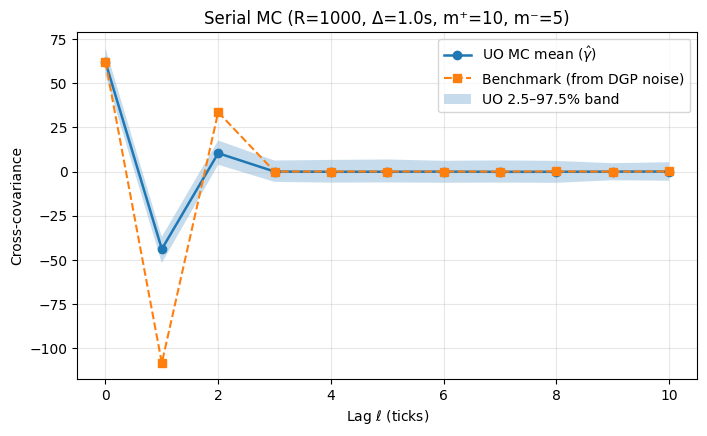

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from uo2009.dgp.params import EfficientPriceParams, NoiseParamsMA2
from uo2009.dgp.simulate import simulate_section4_1_1
from uo2009.estimators.estimate_cross_covariance_uo import estimate_cross_covariance_uo_eq11

# ----------------------------
# Settings
# ----------------------------
eff_params = EfficientPriceParams()
noise_params = NoiseParamsMA2()

delta_seconds = 1.0
L = 10
lags = np.arange(0, L + 1, dtype=int)  # 0..10

m_plus = 10
m_minus = 5

R = 1000
seed0 = 123

# Proper independent seeds
ss = np.random.SeedSequence(seed0)
seeds = ss.generate_state(R, dtype=np.uint32)

# ----------------------------
# Monte Carlo (serial)
# ----------------------------
gamma_hat_all = np.full((R, lags.size), np.nan, dtype=float)
gamma_true_all = np.full((R, lags.size), np.nan, dtype=float)

for r in range(R):
    rng = np.random.default_rng(int(seeds[r]))

    out = simulate_section4_1_1(
        eff_params=eff_params,
        noise_params=noise_params,
        delta_seconds=delta_seconds,
        rng=rng,
    )

    y = out.y_obs
    t_obs = out.t_obs
    y1_obs = y[:, 0]
    y2_obs = y[:, 1]

    t1_obs = np.arange(t_obs.size, dtype=int)
    t2_obs = np.arange(t_obs.size, dtype=int)

    # Eq. (11) estimator
    gamma_hat_all[r, :] = np.array(
        [
            estimate_cross_covariance_uo_eq11(
                t1_obs, y1_obs, t2_obs, y2_obs,
                ell=int(ell),
                m_plus=m_plus,
                m_minus=m_minus,
                ell_in="ticks",
                return_debug=False,
            )
            for ell in lags
        ],
        dtype=float,
    )

    # Benchmark from DGP noise: Cov(eta_t, delta_{t+ell})
    u = out.noise
    eta = u[:, 0].astype(float)
    delt = u[:, 1].astype(float)
    eta = eta - eta.mean()
    delt = delt - delt.mean()

    n = eta.size
    for j, ell in enumerate(lags):
        if ell == 0:
            gamma_true_all[r, j] = float(np.mean(eta * delt))
        else:
            gamma_true_all[r, j] = float(np.mean(eta[: n - ell] * delt[ell:]))

# ----------------------------
# Summary stats
# ----------------------------
mean_uo = np.nanmean(gamma_hat_all, axis=0)
mean_true = np.nanmean(gamma_true_all, axis=0)

# Option 1: 95% CI for MC mean (thin if R is big)
n_eff = np.sum(np.isfinite(gamma_hat_all), axis=0)
sd_uo = np.nanstd(gamma_hat_all, axis=0, ddof=1)
se_uo = sd_uo / np.sqrt(n_eff)
z = 1.96
ci_lo = mean_uo - z * se_uo
ci_hi = mean_uo + z * se_uo

# Option 2: 95% band across replications (usually more visible)
q_lo = np.nanpercentile(gamma_hat_all, 2.5, axis=0)
q_hi = np.nanpercentile(gamma_hat_all, 97.5, axis=0)

# ----------------------------
# Plot (pick ONE band to show)
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(lags, mean_uo, marker="o", linewidth=1.8, label="UO MC mean ($\\hat\\gamma$)")
ax.plot(lags, mean_true, marker="s", linestyle="--", linewidth=1.5, label="Benchmark (from DGP noise)")

# Choose band type:
use_quantile_band = True

if use_quantile_band:
    mask = np.isfinite(q_lo) & np.isfinite(q_hi)
    ax.fill_between(lags[mask], q_lo[mask], q_hi[mask], alpha=0.25, label="UO 2.5–97.5% band")
else:
    mask = np.isfinite(ci_lo) & np.isfinite(ci_hi)
    ax.fill_between(lags[mask], ci_lo[mask], ci_hi[mask], alpha=0.25, label="UO 95% CI (MC mean)")

ax.set_xlabel("Lag $\\ell$ (ticks)")
ax.set_ylabel("Cross-covariance")
ax.set_title(f"Serial MC (R={R}, Δ={delta_seconds}s, m⁺={m_plus}, m⁻={m_minus})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()